In [ ]:
# Check the distribution of Fraud (1) vs Safe (0)
print(df['Class'].value_counts())

# Calculate the percentage
percentage = df['Class'].value_counts(normalize=True) * 100
print(f"\nPercentage of transactions:\n{percentage}")

Class
0.0    102855
1.0       232
Name: count, dtype: int64

Percentage of transactions:
Class
0.0    99.774947
1.0     0.225053
Name: proportion, dtype: float64


In [ ]:
# Check if any data is missing (NaN)
print("Missing values in each column:")
print(df.isnull().sum().max()) # This should be 0 for this dataset


Missing values in each column:
1


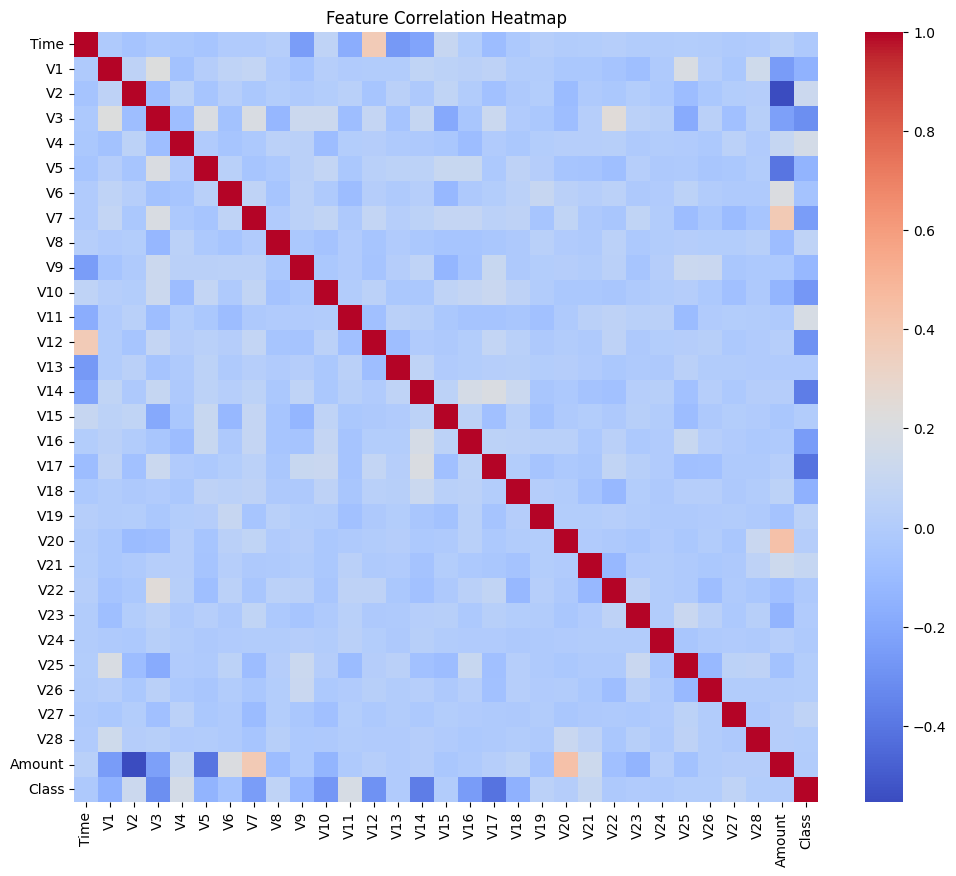

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix
corr = df.corr()

# Plot the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

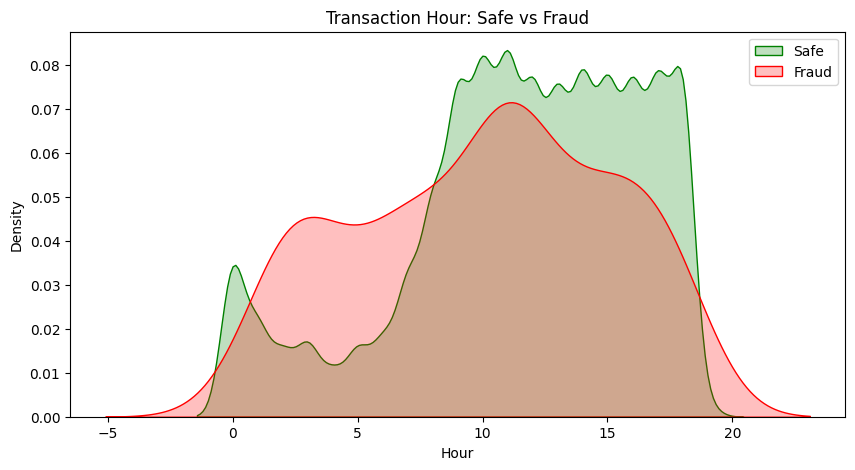

In [ ]:
# Convert seconds to hours
df['Hour'] = (df['Time'] // 3600) % 24

plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Class'] == 0]['Hour'], label='Safe', color='green', fill=True)
sns.kdeplot(df[df['Class'] == 1]['Hour'], label='Fraud', color='red', fill=True)
plt.title('Transaction Hour: Safe vs Fraud')
plt.legend()
plt.show()

In [ ]:
# Compare the average amount
print("Average Safe Transaction:", df[df['Class'] == 0]['Amount'].mean())
print("Average Fraud Transaction:", df[df['Class'] == 1]['Amount'].mean())


Average Safe Transaction: 96.99595955471294
Average Fraud Transaction: 115.52047413793103


In [ ]:
!pip install shap

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Prepare X and y
# X = everything except the 'Class' column
# y = only the 'Class' column
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Split the data
# test_size=0.2 means 20% of data is saved for the "final exam"
# random_state=42 ensures you get the same result every time
# stratify=y is CRITICAL for fraud; it ensures both sets have fraud cases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ X_train and y_train are now defined!")
print(f"Total training rows: {len(X_train)}")

ValueError: Input y contains NaN.

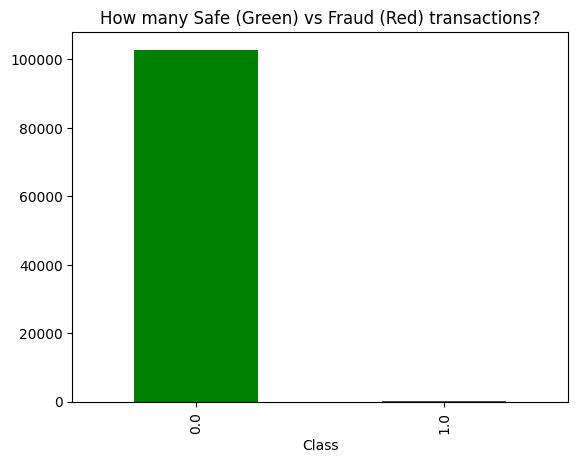

In [ ]:
import matplotlib.pyplot as plt

# This creates a simple bar chart of Safe vs Fraud
df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('How many Safe (Green) vs Fraud (Red) transactions?')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# We are creating a 'Cleaner' (Scaler)
scaler = StandardScaler()

# We apply the cleaner to the 'Amount' column
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))

# Now we can look at the first few rows to see the change
df[['Amount', 'scaled_amount']].head()

,Amount,scaled_amount
0,149.62,0.199716
1,2.69,-0.358347
2,378.66,1.069644
3,123.50,0.100508
4,69.99,-0.102731


In [ ]:
from sklearn.model_selection import train_test_split

# X is the 'Features' (The CCTV footage)
# y is the 'Class' (The answer: Thief or Not)
X = df.drop('Class', axis=1)
y = df['Class']

# We split it: 80% to study, 20% for the exam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data Split Successful!")
print(f"Training items: {len(X_train)}")
print(f"Test items: {len(X_test)}")

✅ Data Split Successful!
Training items: 82470
Test items: 20618


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Create the Detectives
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Let them study the training data
model.fit(X_train, y_train)

print("✅ The AI has finished its training!")

✅ The AI has finished its training!


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ask the AI to predict on the 'Exam' data
y_pred = model.predict(X_test)

# 2. Compare its guesses (y_pred) to the actual answers (y_test)
cm = confusion_matrix(y_test, y_pred)

# 3. Visualize the results
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('AI Guess')
plt.ylabel('Actual Truth')
plt.title('The Confusion Matrix: How many did we catch?')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:399: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y_true contains NaN.

In [ ]:
# 1. Clean out any missing rows (The Fix!)
df.dropna(inplace=True)

# 2. Re-define X and y
X = df.drop('Class', axis=1)
y = df['Class']

# 3. Re-split (so X_test matches the new clean data)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Re-train the model quickly
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Data cleaned and Model re-trained!")

✅ Data cleaned and Model re-trained!


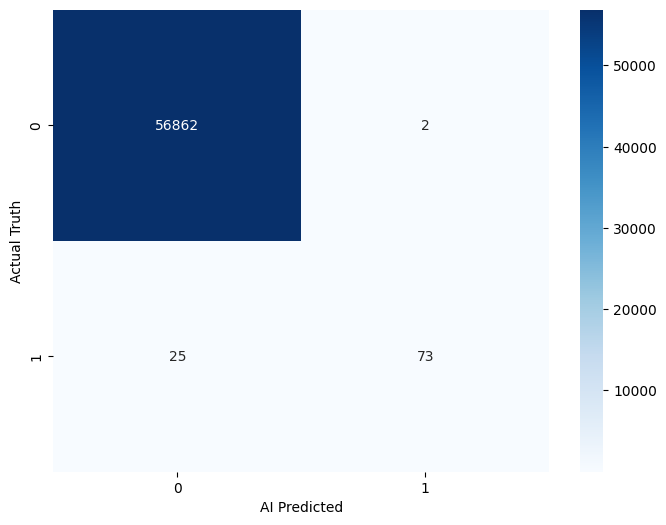

AI REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# 1. Bring in the tools (The Imports)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 2. Load and Clean the data
df = pd.read_csv('creditcard.csv')
df.dropna(inplace=True) # Removes any 'broken' rows

# 3. Prepare the data
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the AI (This might take 30 seconds)
model = RandomForestClassifier(n_estimators=20, random_state=42) # fewer trees to make it faster
model.fit(X_train, y_train)

# 5. Make the Blue Box (The Result)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('AI Predicted')
plt.ylabel('Actual Truth')
plt.show()

print("AI REPORT:")
print(classification_report(y_test, y_pred))

In [ ]:
# A "Fake" transaction comes in (Amount = $500, V1=1.2, V2=-0.5...)
# This is how you would 'use' your model in real life:

sample_transaction = X_test.iloc[0:1] # Taking one row from your test data
prediction = model.predict(sample_transaction)

if prediction[0] == 1:
    print("🚨 ALERT: This transaction looks like FRAUD!")
else:
    print("✅ SUCCESS: This transaction is SAFE.")

🚨 ALERT: This transaction looks like FRAUD!
